A notebook to look at the fraction of cells tuned to different variables (escape, speed, dist_to_shelter) in the escape pattern

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]


session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [2]:
%load_ext autoreload
%autoreload 2
from behave_analysis.process.process import Process
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from settings.settings_analyze_efizz import Settings_ae
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_tuning_stat

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF
conditions = ["shelter_only", "barrier", "flipped_barrier"]
%matplotlib inline

In [3]:
# the settings of the analysis that we want to plot!
settings = {'ep_bins': 25,
            'ep_no_stationary': False,
            'ep_interpolation_mult': 2,
            'ep_gaussian_fitting': False,
            'ep_compute_loo_reliability': False,
            'ep_tuned_compare_method': 'euclidean',
            'ep_tuned_stats': 'bootstrap',
            'ep_tuned_stats_samples': 100,
            'linshift_min_step': 120,
            'linshift_step': 80,
            'linshift_step_n': 100,
            'stim_type': 'audio',
            'cluster_type': 'good',
            'condition_types': 'experimental_conditions',
            'compartment_split': ['all']}
Settings_ae = settings_overrides(Settings_ae, {'redo_compute': False})

colors = [
    "#4363d8",  # Medium blue - different from your blues
    "#C77CFF",   # Light purple - distinct from your darker purple
    "#dcbf46"   # Gold/mustard - not used in your palette
]

The next two cells make bar plots for how many cells are significantly tuned to a given variable... scroll down for plotting residuals!

In [16]:
tuning = "escape in homing&escape" # edit to change the variable to plot
# tuning = "speed in explore" # edit to change the variable to plot

stat = 'zscore_peak' # edit to change the tuning statistic to plot (options: 'peak', 'peak_to_mean', 'zscore_peak')
fraction_sig_session = np.zeros((len(experiments_objects), 3))

for i, e in enumerate(experiments_objects):
    session = Process(e).load_session()
    data_path = os.path.join(session.base_path, session.processed_path, "models", "escape_tuning")
    _, do_analysis, hexaname = check_database_for_same_run(
                                    db_settings={"variable": tuning, **settings},
                                    results_csv_name=data_path + os.sep + "EscapePattern_results.csv",
                                    settings=Settings_ae,
                                )

    if do_analysis:
        print("analysis not done yet for this session {0}! Sad".format(session.name))

    else:
        print("loading data for session {} with hexaname {}".format(session.name, hexaname))
        data = np.load(os.path.join(data_path, "EPtuning_" + hexaname + "_results.npz"), allow_pickle=True)
        real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                                    shifted_matrix=data['fr_shift'], 
                                                    shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                                    neural_matrix=data['neural_matrix'], 
                                                    condition=data['condition'])
        sig_escape = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
        fraction_sig_session[i,:] = np.sum(sig_escape, axis = 1) / sig_escape.shape[1]

2026-03-12 16:06:10.066 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 16:06:10.083 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['e798802f2ced4e21'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL004, Experiment: flip, Run number: 0 with hexaname e798802f2ced4e21


2026-03-12 16:06:12.837 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 16:06:12.856 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['698c04000dc34823'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flipppuf19sept_2023_09_19T14_10_56\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL004, Experiment: flip, Run number: 0 with hexaname 698c04000dc34823


2026-03-12 16:06:14.955 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 16:06:14.998 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 3 matched results in database: ['cfb145e4c84341c6' 'dbdb43e373084b08' '4acb318fadfb4ad3'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\JAL004_flip_rotated_2023_08_28T09_36_04\processed_data\models\escape_tuning\EscapePattern_results.csv


...

loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname 4010dff9453d48b3


2026-03-12 16:06:50.822 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 16:06:50.841 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 2 matched results in database: ['21440fbcc9924f06' '0af09240edb040c0'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_barrier_flip_5_2024_05_14T10_18_03\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname 0af09240edb040c0


2026-03-12 16:06:51.824 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-12 16:06:51.839 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 2 matched results in database: ['7a545f0555704db4' '1b06c867da344f98'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_barrier_flip_4_2024_05_10T11_47_47\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname 1b06c867da344f98


Text(0.5, 1.0, 'escape in homing&escape')

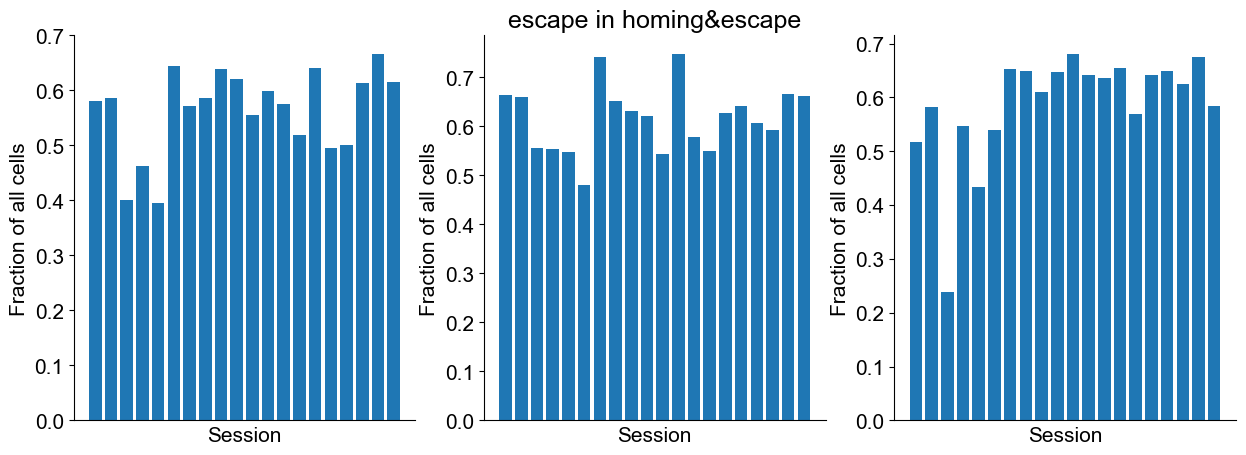

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for c in range(3):
    ax[c].bar(np.arange(fraction_sig_session.shape[0]), fraction_sig_session[:, c])
    ax[c].set_ylabel('Fraction of all cells')
    ax[c].set_xticks([])
    ax[c].set_xlabel('Session')
    ax[c].spines['top'].set_visible(False)
    ax[c].spines['right'].set_visible(False)
ax[1].set_title(tuning)

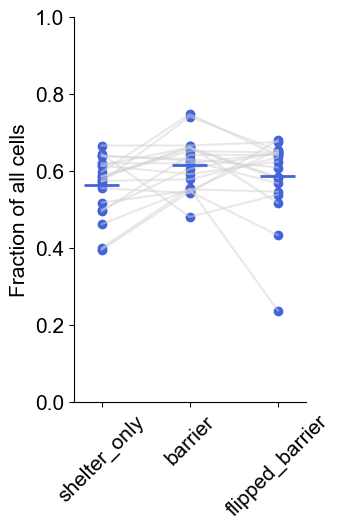

In [18]:
"""Overview plot across sessions as a scatter plot"""
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.plot(fraction_sig_session.T, color = 'lightgrey', alpha = 0.5)
for c in range(3):
    ax.scatter(np.full_like(fraction_sig_session[:, c], c), fraction_sig_session[:, c], color = colors[0])
    ax.hlines(np.mean(fraction_sig_session[:, c]), c - 0.2, c + 0.2, color=colors[0], linewidth=2)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel('Fraction of all cells')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 1)
    # ax.set_title(tuning)

In [30]:
"""A cell to look at some examples of how linear shift breaks the tuning of cells"""
from syd import make_viewer

viewer = make_viewer()
viewer.add_integer("neuron", min = 0, max = sig_escape.shape[1]-1)
viewer.add_integer("condition", min = 0, max = 2)

def plot(state):
    c = state['condition']
    n = state['neuron']
    fig, axs = plt.subplots(1, 3, figsize=(12, 6))

    fr_shifted_no0 = np.delete(data['fr_shift'], int(np.shape(data['fr_shift'])[0] / 2), axis=0)
    ymin = min(np.nanmin(data['fr_full'][c, n, :]), np.nanmin(data['fr_shift'][:, c, n, :]))
    ymax = max(np.nanmax(data['fr_full'][c, n, :]), np.nanmax(data['fr_shift'][:, c, n, :]))

    # subplot 1: original tuning curve
    axs[0].plot(data['fr_full'][c, n, :], 'k', linewidth=2, label='Original FR')
    axs[0].set_ylabel('Firing Rate')
    axs[0].set_title('Original Tuning Curve')
    axs[0].set_ylim(ymin, ymax)

    # subplot 2: shifted tuning curve
    perc95 = np.argmin(shift_stat[:, c, n] - np.percentile(shift_stat[:, c, n], 95))
    # don't plot the shift0 curve
    axs[1].plot(fr_shifted_no0[:, c, n, :].T, 'k', alpha=0.5, linewidth = .5, label='Shifted FR')
    axs[1].plot(data['fr_shift'][perc95, c, n, :], 'k', linewidth=2, label='95th Percentile Shifted FR')
    axs[1].set_title('Shifted Tuning Curves')
    axs[1].set_ylim(ymin, ymax)

    # subplot 3: peak to mean ratio for original and shifted
    axs[2].hist(shift_stat[:, c, n], bins=20, alpha=0.7, label='Shifted Peak-to-Mean')
    axs[2].axvline(real_stat[c, n], color='k', linestyle='--', label='Original Peak-to-Mean')
    axs[2].set_title(stat)
    axs[2].set_ylabel('Number of Shifts')
    axs[2].legend(bbox_to_anchor=(0.5, -.2), loc='upper center')
    axs[2].set_xlabel(stat)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for i in range(2):
        axs[i].set_xticks([0, 12.5, 25])
        if tuning.split(" in ")[0] == "speed":
            axs[i].set_xticklabels([0, 25, 50])
        else:
            # axs[i].set_xticklabels([0, int(data['bin_edges'][-1])/2, int(data['bin_edges'][-1])])
            axs[i].set_xticklabels([0, .5, 1])
        axs[i].set_xlabel(tuning.split(" in ")[0])

    fig.tight_layout()

    return fig

viewer.set_plot(plot)
viewer.show()

The next three cells make bar plots to show fraction of cells tuned to a given variable after regressing out a different variable

In [31]:
tuning = 'residual: escape in homing&escape - speed in explore' # edit to change the variable to plot
res = tuning.split("residual: ")[1]
var = [tuning, res.split(" - ")[0], res.split(" - ")[1]]

fraction_sig_sesh_res = np.zeros((len(var),len(experiments_objects), 3))

for i, e in enumerate(experiments_objects):
    session = Process(e).load_session()
    sig = {}
    for v in var:
        data_path = os.path.join(session.base_path, session.processed_path, "models", "escape_tuning")
        _, do_analysis, hexaname = check_database_for_same_run(
                                        db_settings={"variable": v, **settings},
                                        results_csv_name=data_path + os.sep + "EscapePattern_results.csv",
                                        settings=Settings_ae,
                                )

        if do_analysis:
            print("analysis not done yet for this session {0} for variable {1}! Sad".format(session.name, v))
        else:
            print("loading data for session {} with hexaname {}".format(session.name, hexaname))
            data = np.load(os.path.join(data_path, "EPtuning_" + hexaname + "_results.npz"), allow_pickle=True)
            shift0 = int(np.shape(data['y_fitted_shift'])[0] / 2)
            real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                                        shifted_matrix=data['fr_shift'], 
                                                        shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                                        neural_matrix=data['neural_matrix'], 
                                                        condition=data['condition'])
            s = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
            sig[v] = s[:5,:]
    
    sig_var1 = sig[var[1]] & sig[var[0]] # sig for the first variable (var[1] e.g. escape in homing&escape) after removing residuals (var[0])
    sig_var1_nores = sig[var[1]] & ~sig[var[0]] # sig for the first variable (var[1] e.g. escape in homing&escape) no longer sig after removing activity to second variable (var[2] e.g. bird_dist_shelter in explore)
    sig_var2 = sig[var[2]] & ~sig[var[1]] # sig for the second variable (var[2] e.g. bird_dist_shelter in explore) but not the first (var[1] e.g. escape in homing&escape)
    # NB: these should be completely non-overlapping sets!!
    assert np.sum(sig_var1 & sig_var1_nores) == 0
    assert np.sum(sig_var1 & sig_var2) == 0
    assert np.sum(sig_var1_nores & sig_var2) == 0
    for c in range(3):
        fraction_sig_sesh_res[0,i,c] = np.sum(sig_var1[c,:]) / sig_var1.shape[1]
        fraction_sig_sesh_res[1,i,c] = np.sum(sig_var1_nores[c,:]) / sig_var1_nores.shape[1]
        fraction_sig_sesh_res[2,i,c] = np.sum(sig_var2[c,:]) / sig_var2.shape[1]


2026-03-13 11:18:43.698 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-13 11:18:43.776 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['d9b7dc427bd240e6'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL004, Experiment: flip, Run number: 0 with hexaname d9b7dc427bd240e6


2026-03-13 11:18:46.303 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['e798802f2ced4e21'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL004, Experiment: flip, Run number: 0 with hexaname e798802f2ced4e21


2026-03-13 11:18:48.816 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['ad561b1c7e594ef0'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\escape_tuning\EscapePattern_results.csv


...

loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname 4355de18ec8c4b7c


2026-03-13 11:30:55.997 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 2 matched results in database: ['7a545f0555704db4' '1b06c867da344f98'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_barrier_flip_4_2024_05_10T11_47_47\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname 1b06c867da344f98


2026-03-13 11:30:56.816 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['c1d5e8c22a434dc0'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_barrier_flip_4_2024_05_10T11_47_47\processed_data\models\escape_tuning\EscapePattern_results.csv


loading data for session Mouse: JAL008, Experiment: flip, Run number: 7 with hexaname c1d5e8c22a434dc0


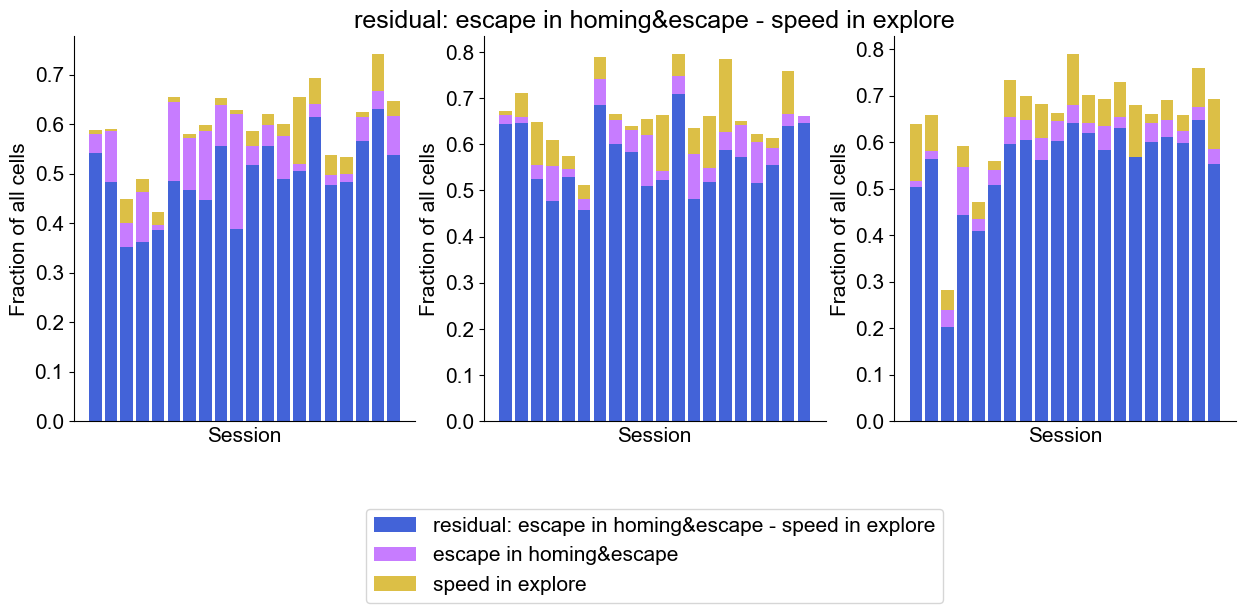

In [32]:
labels = ['sig. ' + var[1].split(" in ")[0], 'not sig. ' + var[1].split(" in ")[0], 'sig. ' + var[2].split(" in ")[0]]
c = 0
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for c in range(3):
    # make a stacked bar plot with the three categories (sig_var1, sig_var1_nores, sig_var2) in different colors
    for s in range(fraction_sig_sesh_res.shape[1]):
        bottom = 0
        for i in range(fraction_sig_sesh_res.shape[0]):
            ax[c].bar(s, fraction_sig_sesh_res[i,s,c], 
                bottom=bottom, color=colors[i], label=var[i] if s == 0 else "")
            bottom += fraction_sig_sesh_res[i,s,c]
    ax[c].set_ylabel('Fraction of all cells')
    ax[c].set_xticks([])
    ax[c].set_xlabel('Session')
    ax[c].spines['top'].set_visible(False)
    ax[c].spines['right'].set_visible(False)
ax[1].set_title(tuning)
ax[1].legend(bbox_to_anchor=(0.5, -.2), loc='upper center')

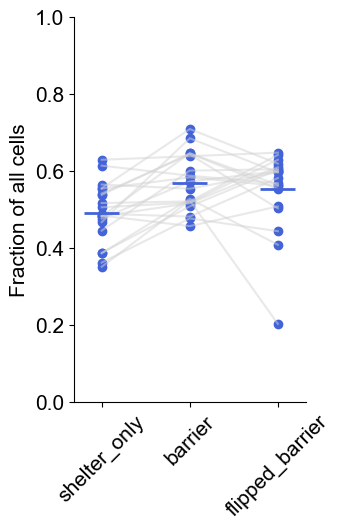

In [33]:
"""Overview plot across sessions as a scatter plot
Only plotting the ones tuned to var[1] that are still tuned after removing var[2]"""
fig, ax = plt.subplots(1, 1, figsize=(3,5))
ax.plot(fraction_sig_sesh_res[0,:,:].T, color = 'lightgrey', alpha = 0.5)
for c in range(3):
    ax.scatter(np.full_like(fraction_sig_sesh_res[0,:, c], c), fraction_sig_sesh_res[0,:, c], color = colors[0])
    ax.hlines(np.mean(fraction_sig_sesh_res[0,:, c]), c - 0.2, c + 0.2, color=colors[0], linewidth=2)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel('Fraction of all cells')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 1)
    title = tuning.split("residual: ")[1].split(" - ")[0] + "\n - " + tuning.split(" - ")[1]
    # ax.set_title(title)